
# Reward Learner Demo (MiniGrid-style 2D Navigation)

This notebook demonstrates:
1. **Dataset generation** of *minimal-pair* trajectories (shared prefix, single divergent decision).
2. A **Bradley–Terry (logit) reward learner** with a Q-head that scores trajectories.
3. **Visualizations**: sample minimal pairs and heatmaps of the learned value \(V(s)\) and \(\max_a Q(s,a)\).

> Note: In your repo, you would import these from `src.reward_learner.reward_learner` and `src.environment_generator.custom_minigrid`.
For the purposes of this demo, we include compact, self-contained versions that match the interfaces.


In [8]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import math, os, sys
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)
from environment_generator.custom_minigrid import Simple2DNavigationEnv


# -----------------------------
# Data structures (MiniGrid-aware)
# -----------------------------

@dataclass(frozen=True)
class S2DState:
    x: int
    y: int

@dataclass(frozen=True)
class S2DStep:
    s: S2DState
    a: int  # one of Simple2DNavigationEnv.Actions (0..3)

@dataclass
class Trajectory:
    steps: List[S2DStep]
    success: Optional[bool] = None
    # Optional: stash episode metadata if useful (start_pos, goal_pos, etc.)

Pair = Tuple[Trajectory, Trajectory, int]  # y in {0,1}; 1 means first preferred

## Define features and Q network

In [11]:

# -----------------------------
# Action helpers tied to your env
# -----------------------------

A_LEFT  = Simple2DNavigationEnv.Actions.LEFT
A_RIGHT = Simple2DNavigationEnv.Actions.RIGHT
A_UP    = Simple2DNavigationEnv.Actions.UP
A_DOWN  = Simple2DNavigationEnv.Actions.DOWN

ALL_ACTIONS = [A_LEFT, A_RIGHT, A_UP, A_DOWN]

def action_onehot(a: int) -> torch.Tensor:
    v = torch.zeros(4, dtype=torch.float32)
    v[a] = 1.0
    return v

# -----------------------------
# Featurization (MiniGrid-aware)
# -----------------------------

def state_features(
    s: S2DState,
    grid_size: int,
    goal_pos: Tuple[int, int],
    step_frac: Optional[float] = None,
) -> torch.Tensor:
    """
    Returns a feature vector:
      [ x/W, y/W, gx/W, gy/W, d_manhattan/W, step_frac? ]
    where W = grid_size-1 (normalize to [0,1]).
    `step_frac` can encode time pressure: step_count / max_steps (optional).
    """
    W = max(grid_size - 1, 1)
    gx, gy = goal_pos
    dx = abs(gx - s.x)
    dy = abs(gy - s.y)
    feats = [
        s.x / W,
        s.y / W,
        gx / W,
        gy / W,
        (dx + dy) / W,
    ]
    if step_frac is not None:
        feats.append(step_frac)
    return torch.tensor(feats, dtype=torch.float32)

def feature_dim(include_step_frac: bool) -> int:
    return 6 if include_step_frac else 5  # (x,y,gx,gy,dman[,stepfrac])

# -----------------------------
# Q-network (MiniGrid-aware)
# -----------------------------

class QNet(nn.Module):
    def __init__(self, state_dim: int, hidden: int = 128):
        super().__init__()
        # Input: state_dim + 4 (action one-hot)
        self.mlp = nn.Sequential(
            nn.Linear(state_dim + 4, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, sa: torch.Tensor) -> torch.Tensor:
        # sa: [B, state_dim + 4]
        return self.mlp(sa).squeeze(-1)  # [B]

## Scoring function and Bradley-Terry loss for reward learner

In [12]:

# -----------------------------
# Scoring functions
# -----------------------------

def score_trajectory_Q(
    traj: Trajectory,
    qnet: QNet,
    grid_size: int,
    goal_pos: Tuple[int, int],
    max_steps: Optional[int] = None,
    include_step_frac: bool = False,
) -> torch.Tensor:
    """
    S(τ) = Σ_t [ Q(s_t, a_t) - V(s_t) ], V(s) = log Σ_a exp Q(s,a).
    When include_step_frac=True and max_steps provided, a normalized time feature is added.
    """
    total = torch.tensor(0.0, dtype=torch.float32)
    for t, step in enumerate(traj.steps):
        step_frac = None
        if include_step_frac and max_steps is not None and max_steps > 0:
            step_frac = float(t) / float(max_steps)
        feats_s = state_features(step.s, grid_size, goal_pos, step_frac)  # [state_dim]
        # Q for all actions to compute V(s)
        q_all = []
        for a in ALL_ACTIONS:
            sa = torch.cat([feats_s, action_onehot(a)])  # [state_dim+4]
            q = qnet(sa.unsqueeze(0)).squeeze(0)
            q_all.append(q)
        q_all = torch.stack(q_all, dim=0)  # [4]
        v = torch.logsumexp(q_all, dim=0)  # scalar
        # Q for chosen action
        sa_chosen = torch.cat([feats_s, action_onehot(step.a)]).unsqueeze(0)
        q_chosen = qnet(sa_chosen).squeeze(0)
        total = total + (q_chosen - v)
    return total  # scalar tensor

# -----------------------------
# Losses & metrics
# -----------------------------

def bt_pairwise_loss(
    pairs: List[Pair],
    qnet: QNet,
    grid_size: int,
    goal_pos: Tuple[int, int],
    max_steps: Optional[int] = None,
    include_step_frac: bool = False,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    logits = []
    labels = []
    for A, B, y in pairs:
        SA = score_trajectory_Q(A, qnet, grid_size, goal_pos, max_steps, include_step_frac)
        SB = score_trajectory_Q(B, qnet, grid_size, goal_pos, max_steps, include_step_frac)
        logits.append((SA - SB).unsqueeze(0))
        labels.append(y)
    logits = torch.cat(logits, dim=0)  # [N]
    labels_t = torch.tensor(labels, dtype=torch.float32)
    loss = F.binary_cross_entropy_with_logits(logits, labels_t)
    preds = (torch.sigmoid(logits) > 0.5).float()
    acc = (preds == labels_t).float().mean().item()
    margin = torch.abs(logits).mean().item()
    return loss, {"pair_acc": acc, "avg_margin": margin}


## Reward learner class

In [13]:

# -----------------------------
# Learner wrapper (MiniGrid-aware)
# -----------------------------

class RewardLearnerMiniGrid:
    """
    A Bradley–Terry reward learner with a Q-head, tailored to Simple2DNavigationEnv.
    """
    def __init__(
        self,
        grid_size: int,
        goal_pos: Tuple[int, int],
        include_step_frac: bool = False,
        hidden: int = 128,
        device: str = "cpu",
    ):
        self.grid_size = grid_size
        self.goal_pos = goal_pos
        self.include_step_frac = include_step_frac
        self.device = torch.device(device)
        sdim = feature_dim(include_step_frac)
        self.qnet = QNet(state_dim=sdim, hidden=hidden).to(self.device)

    def fit(
        self,
        pair_dataset: List[Pair],
        epochs: int = 20,
        batch_size: int = 16,
        lr: float = 1e-3,
        grad_clip: Optional[float] = 1.0,
        verbose: bool = True,
        seed: int = 0,
        max_steps_hint: Optional[int] = None,
    ):
        """
        Train on pairwise preferences. `max_steps_hint` helps set the time feature if enabled.
        """
        torch.manual_seed(seed)
        opt = torch.optim.Adam(self.qnet.parameters(), lr=lr)
        n = len(pair_dataset)
        for ep in range(1, epochs + 1):
            random.shuffle(pair_dataset)
            total_loss = total_acc = total_margin = 0.0
            batches = 0
            for i in range(0, n, batch_size):
                batch_pairs = pair_dataset[i:i + batch_size]
                opt.zero_grad(set_to_none=True)
                loss_bt, metrics = bt_pairwise_loss(
                    batch_pairs, self.qnet,
                    grid_size=self.grid_size,
                    goal_pos=self.goal_pos,
                    max_steps=max_steps_hint,
                    include_step_frac=self.include_step_frac,
                )
                loss = loss_bt
                loss.backward()
                if grad_clip is not None:
                    nn.utils.clip_grad_norm_(self.qnet.parameters(), grad_clip)
                opt.step()
                total_loss += loss.item()
                total_acc += metrics["pair_acc"]
                total_margin += metrics["avg_margin"]
                batches += 1
            if verbose:
                print(f"[ep {ep:03d}] loss={total_loss/max(batches,1):.4f} "
                      f"pair_acc={total_acc/max(batches,1):.3f} "
                      f"margin={total_margin/max(batches,1):.3f}")

    # ---- Visualizations (heatmaps) ----
    @torch.no_grad()
    def V_map(self) -> np.ndarray:
        V = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        for y in range(self.grid_size):
            for x in range(self.grid_size):
                s = S2DState(x, y)
                feats = state_features(
                    s, self.grid_size, self.goal_pos,
                    step_frac=(0.0 if self.include_step_frac else None),
                )
                q_all = []
                for a in ALL_ACTIONS:
                    sa = torch.cat([feats, action_onehot(a)]).unsqueeze(0)
                    q_all.append(self.qnet(sa).squeeze(0))
                q_all = torch.stack(q_all, dim=0)
                V[y, x] = torch.logsumexp(q_all, dim=0).item()
        return V

    @torch.no_grad()
    def Q_star_map(self) -> np.ndarray:
        Qmax = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        for y in range(self.grid_size):
            for x in range(self.grid_size):
                s = S2DState(x, y)
                feats = state_features(
                    s, self.grid_size, self.goal_pos,
                    step_frac=(0.0 if self.include_step_frac else None),
                )
                vals = []
                for a in ALL_ACTIONS:
                    sa = torch.cat([feats, action_onehot(a)]).unsqueeze(0)
                    vals.append(self.qnet(sa).squeeze(0).item())
                Qmax[y, x] = max(vals)
        return Qmax

## Sample dataset generator
labeling approach: prefer greedy-first (A) over detour-first (B); add some noise

In [26]:

# -----------------------------
# MiniGrid-aware minimal-pair generator
# -----------------------------

def greedy_action_toward(s: S2DState, goal: Tuple[int, int]) -> int:
    gx, gy = goal
    # Choose the action that reduces Manhattan distance (tie-break randomly)
    candidates = []
    if gx > s.x: candidates.append(A_RIGHT)
    if gx < s.x: candidates.append(A_LEFT)
    if gy > s.y: candidates.append(A_DOWN)
    if gy < s.y: candidates.append(A_UP)
    if not candidates:
        return random.choice(ALL_ACTIONS)
    return random.choice(candidates)

def apply_action_local(s: S2DState, a: int, grid_size: int) -> S2DState:
    # Mirrors your env semantics: set dir then move forward one step.
    x, y = s.x, s.y
    if a == A_LEFT:  x = max(1, x - 1)   # walls at 0 and size-1; keep inside 1..size-2
    if a == A_RIGHT: x = min(grid_size - 2, x + 1)
    if a == A_UP:    y = max(1, y - 1)
    if a == A_DOWN:  y = min(grid_size - 2, y + 1)
    return S2DState(x, y)

def make_minimal_pair_minigrid(
    start: S2DState,
    goal: Tuple[int, int],
    grid_size: int,
    prefix_len: int = 3,
    tail_len: int = 3,
) -> Tuple[Trajectory, Trajectory]:
    """
    Creates two trajectories:
      - Shared prefix of `prefix_len` greedy moves toward the goal.
      - Divergence at one key state: greedy vs a non-greedy detour.
      - Each gets a short greedy tail of length `tail_len`.
    Keeps positions within [1, size-2] to respect your border walls.
    """
    # Shared prefix
    s = S2DState(start.x, start.y)
    prefix_steps: List[S2DStep] = []
    for _ in range(prefix_len):
        a = greedy_action_toward(s, goal)
        prefix_steps.append(S2DStep(S2DState(s.x, s.y), a))
        s = apply_action_local(s, a, grid_size)

    s_key = S2DState(s.x, s.y)
    a_greedy = greedy_action_toward(s_key, goal)
    # Pick a detour action that is not a_greedy (try to make it "anti-progress")
    detour_candidates = [a for a in ALL_ACTIONS if a != a_greedy]
    a_detour = random.choice(detour_candidates)

    def rollout(s0: S2DState, first_a: int) -> List[S2DStep]:
        cur = S2DState(s0.x, s0.y)
        steps = [S2DStep(S2DState(cur.x, cur.y), first_a)]
        cur = apply_action_local(cur, first_a, grid_size)
        for _ in range(tail_len):
            a = greedy_action_toward(cur, goal)
            steps.append(S2DStep(S2DState(cur.x, cur.y), a))
            cur = apply_action_local(cur, a, grid_size)
        return steps

    tail_A = rollout(s_key, a_greedy)
    tail_B = rollout(s_key, a_detour)

    tau_A = Trajectory(steps=prefix_steps + tail_A, success=True)
    tau_B = Trajectory(steps=prefix_steps + tail_B, success=True)
    return tau_A, tau_B

def demo_pair_dataset_minigrid(
    grid_size: int = 10,
    n_pairs: int = 200,
    seed: int = 0,
    goal_pos: Optional[Tuple[int, int]] = None,
) -> Tuple[List[Pair], Tuple[int,int]]:
    random.seed(seed)
    if goal_pos is None:
        gx = random.randint(1, grid_size - 2)
        gy = random.randint(1, grid_size - 2)
        goal_pos = (gx, gy)
    pairs: List[Pair] = []
    for _ in range(n_pairs):
        sx = random.randint(1, grid_size - 2)
        sy = random.randint(1, grid_size - 2)
        while (sx, sy) == goal_pos:
            sx = random.randint(1, grid_size - 2)
            sy = random.randint(1, grid_size - 2)
        A, B = make_minimal_pair_minigrid(S2DState(sx, sy), goal_pos, grid_size)
        # Label: prefer greedy-first (A) over detour-first (B); add some noise
        y = 1
        if random.random() < 0.1:
            y = 1 - y
        pairs.append((A, B, y))
    return pairs, goal_pos


def plot_grid_with_traj(grid_size: int, goal: Tuple[int, int], traj: Trajectory, title: str):
    # Draw grid, start, goal, and the path (as step-to-step segments)
    xs = [step.s.x for step in traj.steps] + [traj.steps[-1].s.x]
    ys = [step.s.y for step in traj.steps] + [traj.steps[-1].s.y]
    # The end position after last action
    last = traj.steps[-1]
    end = apply_action_local(last.s, last.a, grid_size)
    xs[-1] = end.x
    ys[-1] = end.y

    plt.figure()
    plt.title(title)
    plt.xlim(0, grid_size-1)
    plt.ylim(0, grid_size-1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    # Start (first state's position)
    start_x, start_y = traj.steps[0].s.x, traj.steps[0].s.y
    plt.scatter([start_x], [start_y], marker='v', s=150, color='r', label='start')
    # Goal
    plt.scatter([goal[0]], [goal[1]], marker='*', s=150, color='green', label='goal')
    # Path
    plt.plot(xs, ys, marker='o')
    plt.legend()

def preview_minimal_pairs(pairs: List[Pair], goal: Tuple[int, int], grid_size: int, k: int = 2):
    # Show k minimal pairs (2 figures per pair)
    for i in range(min(k, len(pairs))):
        A, B, y = pairs[i]
        plot_grid_with_traj(grid_size, goal, A, f"Pair {i+1} - A (label y={y})")
        plot_grid_with_traj(grid_size, goal, B, f"Pair {i+1} - B (label y={y})")


## 1. Generate 30 pairs of trajectories for demo

### Fixing the goal location, visualizing two pairs of trajectories with different starting points

Sample task: grid size = 10  goal = (1, 5)


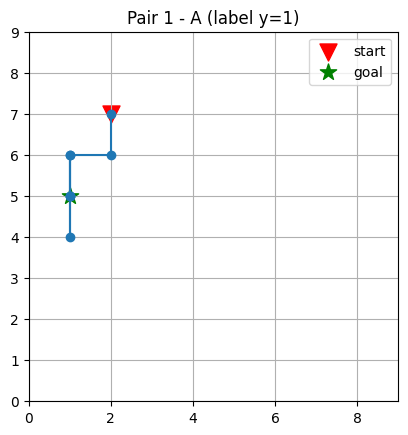

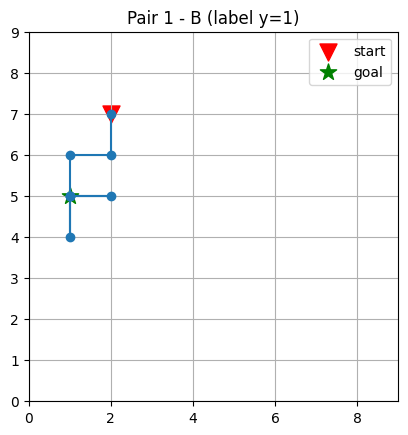

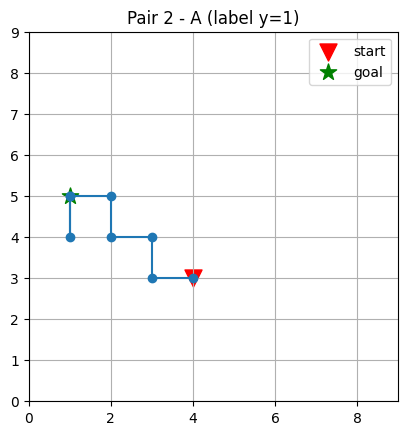

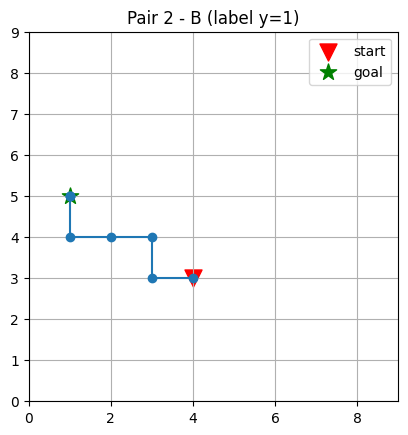

In [37]:
GRID = 10
pairs, goal = demo_pair_dataset_minigrid(grid_size=GRID, n_pairs=100, seed=123)
print("Sample task: grid size =", GRID, " goal =", goal)
# Show two minimal pairs as requested (two plots per pair)
preview_minimal_pairs(pairs, goal, GRID, k=2)

### Example trajectory and label

In [38]:
t1, t2, label = pairs[0]
print('Trajectory A:\n', t1, '\n\nTrajectory B:\n', t1, '\n\nPreference label (1 means A>B): ', label)

Trajectory A:
 Trajectory(steps=[S2DStep(s=S2DState(x=2, y=7), a=<Actions.UP: 2>), S2DStep(s=S2DState(x=2, y=6), a=<Actions.LEFT: 0>), S2DStep(s=S2DState(x=1, y=6), a=<Actions.UP: 2>), S2DStep(s=S2DState(x=1, y=5), a=<Actions.DOWN: 3>), S2DStep(s=S2DState(x=1, y=6), a=<Actions.UP: 2>), S2DStep(s=S2DState(x=1, y=5), a=<Actions.UP: 2>), S2DStep(s=S2DState(x=1, y=4), a=<Actions.DOWN: 3>)], success=True) 

Trajectory B:
 Trajectory(steps=[S2DStep(s=S2DState(x=2, y=7), a=<Actions.UP: 2>), S2DStep(s=S2DState(x=2, y=6), a=<Actions.LEFT: 0>), S2DStep(s=S2DState(x=1, y=6), a=<Actions.UP: 2>), S2DStep(s=S2DState(x=1, y=5), a=<Actions.DOWN: 3>), S2DStep(s=S2DState(x=1, y=6), a=<Actions.UP: 2>), S2DStep(s=S2DState(x=1, y=5), a=<Actions.UP: 2>), S2DStep(s=S2DState(x=1, y=4), a=<Actions.DOWN: 3>)], success=True) 

Preference label (1 means A>B) 1


## 2. train on generated pairs

In [39]:
learner = RewardLearnerMiniGrid(grid_size=GRID, goal_pos=goal, include_step_frac=True, hidden=128)
# Use the same default as your env: ~4 * size^2
learner.fit(pairs, epochs=12, batch_size=16, lr=1e-3, max_steps_hint=4*GRID*GRID, seed=42)

[ep 001] loss=0.6957 pair_acc=0.527 margin=0.049
[ep 002] loss=0.6704 pair_acc=0.679 margin=0.102
[ep 003] loss=0.6684 pair_acc=0.652 margin=0.223
[ep 004] loss=0.6524 pair_acc=0.679 margin=0.293
[ep 005] loss=0.6609 pair_acc=0.625 margin=0.342
[ep 006] loss=0.6789 pair_acc=0.661 margin=0.432
[ep 007] loss=0.6356 pair_acc=0.688 margin=0.395
[ep 008] loss=0.6237 pair_acc=0.688 margin=0.418
[ep 009] loss=0.6175 pair_acc=0.714 margin=0.460
[ep 010] loss=0.6201 pair_acc=0.679 margin=0.504
[ep 011] loss=0.6235 pair_acc=0.652 margin=0.628
[ep 012] loss=0.6159 pair_acc=0.679 margin=0.620


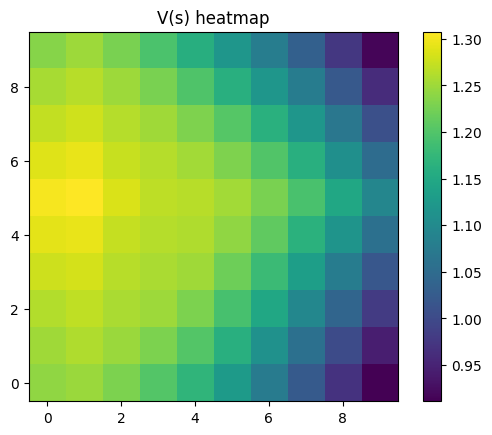

In [54]:

V = learner.V_map()
Qmax = learner.Q_star_map()

plt.figure()
plt.title("V(s) heatmap")
plt.imshow(V, origin="lower")
plt.colorbar()
